In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
url = "https://github.com/IamArunavaSamanta/NeuralRetailProject/raw/main/data/processed/cleaned_online_retail.csv.gz"
df = pd.read_csv("../data/processed/cleaned_online_retail.csv.gz", compression="gzip")
df.head(2)  


C:\Users\ARUNAVA\AppData\Local\Temp\ipykernel_17196\2933405219.py:2: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_online_retail.csv.gz", compression="gzip")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [3]:
# This handles the missing values without crashing
df['CustomerID'] = df['CustomerID'].astype(float).astype('Int64')
df['TotalAmount'] = df['Quantity'] * df['Price']
df['Description'] = df['Description'].fillna('Unknown')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
# Set a "Snapshot Date" (1 day after the last transaction in the data)
# If a customer made a purchase on the very last day of your dataset and you use that same day as your calculation point, their Recency would be 0.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate by Customer
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                   # Monetary
}).reset_index()

customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [5]:
# 1 if Recency > 90 days, else 0
customer_df['Churn'] = (customer_df['Recency'] > 90).astype(int)
print(customer_df['Churn'].value_counts())

Churn
1    2989
0    2889
Name: count, dtype: int64


In [6]:
X = customer_df[['Frequency', 'Monetary']] # Don't use Recency, it's too tied to the target!
y = customer_df['Churn']

In [7]:
X = customer_df[['Frequency', 'Monetary']] # Don't use Recency, it's too tied to the target!
y = customer_df['Churn']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.56      0.60       589
           1       0.61      0.68      0.64       587

    accuracy                           0.62      1176
   macro avg       0.62      0.62      0.62      1176
weighted avg       0.62      0.62      0.62      1176



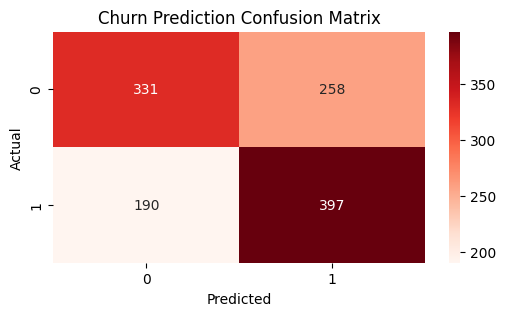

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Prediction Confusion Matrix')
plt.show()